In [1]:
import polars as pl
import numpy as np

In [2]:
from matplotlib import pyplot as plt

In [3]:
USE_VAR = True

In [4]:
df = pl.read_csv("../data/stockdata3.csv")

In [5]:
stocks = [c for c in df.columns if c != "day" and c != "timestr"]
returns = [f"r{s}" for s in stocks]

In [6]:
INTRA = 0
EXTRA = 1
CLOSE = 2


def get_ret(df, s):
    return (
        df.sort("datetime")
        .fill_nan(None)
        .select(
            [
                pl.col("day"),
                pl.col("datetime"),
                ((pl.col(s) / pl.col(s).shift(1)).log() * 1e4).alias(f"r{s}"),
            ]
        )
        .with_columns(
            [
                pl.when(pl.col("day").diff() == 0)
                .then(pl.lit(INTRA))
                .otherwise(pl.lit(EXTRA))
                .alias("return_type")
            ]
        )
    )


def get_ret_cc(df, s):
    return (
        df.sort("datetime")
        .fill_nan(None)
        .group_by("day")
        .agg([pl.col(s).drop_nulls().last()])
        .sort("day")  # must sort before shift(1), group_by output is unordered
        .with_columns(
            [
                ((pl.col(s) / pl.col(s).shift(1)).log() * 1e4).alias(f"r{s}"),
                pl.lit(CLOSE).alias("return_type"),
            ]
        )
    )


def get_ret_all(df, s):
    ret = get_ret(df, s[0])
    for stock in s[1:]:
        print(stock)
        ret = ret.join(get_ret(df, stock), on="datetime", how="inner")

    return ret


In [7]:
def daily_var_from_ret(df, ret):
    return df.group_by("day").agg(pl.col(ret).pow(2).sum())



def daily_var(df, stocks, return_type=None):

    mask = (
        pl.col("return_type") == return_type
        if return_type is not None
        else pl.lit(True)
    )
    if isinstance(stocks, str):
        stocks = [stocks]
    returns = [f"r{s}" for s in stocks]
    vols = daily_var_from_ret(get_ret(df, stocks[0]).filter(mask), returns[0])
    for s, r in zip(stocks[1:], returns[1:]):
        vols = vols.join(daily_var_from_ret(get_ret(df, s).filter(mask), r), on="day")
    return vols


def combine_intraday_gap_var(intraday_vars, gap_vars, returns, day_col="day"):
    """Combine intraday RV and overnight gap RV on the daily-vol scale."""
    joined = intraday_vars.join(
        gap_vars.select(day_col, *returns), on=day_col, how="left", suffix="_gap"
    )
    return joined.with_columns(
        [
            (pl.col(r) + pl.col(f"{r}_gap").fill_null(0)).alias(r) 
            for r in returns
        ]
    ).select(day_col, *returns)

In [8]:
# deal with c: likely split
def normalize_c(df):
    idxs = df.filter(pl.col("c").diff().abs() > 0.4 * pl.col("c"))["index"]
    if len(idxs) > 0:
        index = idxs[0]
    else:
        return df
    print(index)
    return df.with_columns(
        pl.when(pl.col("index") < index)
        .then(pl.col("c") / 2)
        .otherwise(pl.col("c"))
        .alias("c")
    )

In [9]:
#
def mask_micro_noise(col, thd=100, neighbor=1):
    ratio = thd / 1e4  # bps
    ret = (pl.col(col) / pl.col(col).shift(1)).log()
    mask = pl.lit(False)
    for n in range(1, neighbor + 1):
        mask |= (
            (ret * ret.shift(-n) < 0)
            & (ret.abs() > ratio)
            & (ret.shift(-n).abs() > ratio)
        )
    return mask


def mask_denoised(col, thd=100, neighbor=1):
    return ~mask_micro_noise(col, thd, neighbor)


In [10]:
def downsample(df, freq, keep_open=True):
    sample_time = "__sample_datetime"
    sampled = (
        df.with_columns(pl.col("datetime").alias(sample_time))
        .group_by_dynamic("datetime", every=freq, group_by="day")
        .agg(
            pl.exclude(["day", "datetime", sample_time]).last(),
            pl.col(sample_time).last(),
        )
        .drop("datetime")
        .rename({sample_time: "datetime"})
    )
    if keep_open:
        opens = df.sort("datetime").group_by("day", maintain_order=True).head(1)
        sampled = pl.concat([opens, sampled], how="diagonal_relaxed").unique(
            ["day", "datetime"], keep="first"
        )
    return sampled.sort(["day", "datetime"])

In [11]:
def var_to_target(var):
    return np.sqrt(var * 252) / 100

## load data

In [12]:
df = (
    df.with_columns(
        (pl.date(2000, 1, 1) + pl.duration(days=pl.col("day") - 1))
        .dt.combine(pl.col("timestr").str.to_time("%H:%M:%S"))
        .alias("datetime")
    )
    if "datetime" not in df.columns
    else df
)
display(df.select("day", "timestr", "datetime"))
df = df.with_row_index() if "index" not in df.columns else df

day,timestr,datetime
i64,str,datetime[μs]
1,"""09:30:00""",2000-01-01 09:30:00
1,"""09:31:00""",2000-01-01 09:31:00
1,"""09:32:00""",2000-01-01 09:32:00
1,"""09:33:00""",2000-01-01 09:33:00
1,"""09:34:00""",2000-01-01 09:34:00
…,…,…
362,"""15:56:00""",2000-12-27 15:56:00
362,"""15:57:00""",2000-12-27 15:57:00
362,"""15:58:00""",2000-12-27 15:58:00


In [13]:
print(len(df['day'].unique()))

252


In [14]:
# clean a and d
df = df.with_columns(
    pl.when(pl.col("a") == 0).then(None).otherwise(pl.col("a")).alias("a"),
    pl.when(pl.col("d") == 1).then(None).otherwise(pl.col("d")).alias("d"),
)
# clean c
df = normalize_c(df)
# filter d
NOISE_THD = 100  # 100 bps
# df = df.filter(mask_denoised("d", NOISE_THD))

39882


In [15]:
# categories:
stocks_normal = ["a", "c", "e"]  # leave it as is
stocks_downsample_5min_denoise = ["d"]  # down sample to 5min
stocks_downsample_120min = ["b"]  # down sample to 120min
stocks_jump = ["f"]  # special treat, do Poisson jump or monthly close-close volatility

In [16]:
display(downsample(df, "10m"))

day,index,timestr,a,b,c,d,e,f,datetime
i64,u32,str,f64,f64,f64,f64,f64,f64,datetime[μs]
1,0,"""09:30:00""",325.45,13.795,47.25,49.985,49.93,17.025,2000-01-01 09:30:00
1,9,"""09:39:00""",326.225,14.055,47.2875,50.06,49.95,17.025,2000-01-01 09:39:00
1,19,"""09:49:00""",327.765,13.905,47.3325,50.245,49.89,17.025,2000-01-01 09:49:00
1,29,"""09:59:00""",327.43,13.875,47.3175,50.275,49.98,17.025,2000-01-01 09:59:00
1,39,"""10:09:00""",328.165,14.005,47.25,50.245,49.88,17.025,2000-01-01 10:09:00
…,…,…,…,…,…,…,…,…,…
362,98320,"""15:29:00""",405.03,5.625,45.417,45.855,43.47,10.745,2000-12-27 15:29:00
362,98330,"""15:39:00""",404.94,5.515,45.405,45.845,43.66,10.745,2000-12-27 15:39:00
362,98340,"""15:49:00""",404.735,5.615,45.395,45.845,43.64,10.745,2000-12-27 15:49:00


In [17]:
df

index,day,timestr,a,b,c,d,e,f,datetime
u32,i64,str,f64,f64,f64,f64,f64,f64,datetime[μs]
0,1,"""09:30:00""",325.45,13.795,47.25,49.985,49.93,17.025,2000-01-01 09:30:00
1,1,"""09:31:00""",325.245,13.89,47.2575,49.99,49.96,17.025,2000-01-01 09:31:00
2,1,"""09:32:00""",325.58,13.905,47.2825,49.995,49.96,17.025,2000-01-01 09:32:00
3,1,"""09:33:00""",325.47,13.955,47.3225,50.065,49.92,17.025,2000-01-01 09:33:00
4,1,"""09:34:00""",325.295,13.975,47.29,50.03,49.9,17.025,2000-01-01 09:34:00
…,…,…,…,…,…,…,…,…,…
98347,362,"""15:56:00""",404.825,5.515,45.352,45.305,43.57,10.745,2000-12-27 15:56:00
98348,362,"""15:57:00""",404.815,5.615,45.362,45.795,43.61,10.745,2000-12-27 15:57:00
98349,362,"""15:58:00""",404.915,5.625,45.352,45.805,43.63,10.755,2000-12-27 15:58:00


In [18]:
USE_VAR

True

In [19]:
var = daily_var(df, stocks_normal + stocks_jump, return_type=INTRA)
var = var.join(
    daily_var(
        downsample(df.filter(mask_denoised("d", NOISE_THD)), "5m"),
        stocks_downsample_5min_denoise,
        return_type=INTRA,
    ),
    on="day",
)
var = var.join(
    daily_var(downsample(df, "120m"), stocks_downsample_120min, return_type=INTRA),
    on="day",
).sort("day")

#intraday computed

var_gap = daily_var(df, stocks, return_type=EXTRA).sort("day")
var = combine_intraday_gap_var(var, var_gap, returns).sort("day")
# total var computed

# close-to-close daily returns, one row per day --- join on day (not concat:
# each get_ret_cc frame is 1-row-per-day, a horizontal concat would misalign).
ret_cc = get_ret_cc(df, stocks[0]).select("day", f"r{stocks[0]}")
for s in stocks[1:]:
    ret_cc = ret_cc.join(get_ret_cc(df, s).select("day", f"r{s}"), on="day")
ret_cc = ret_cc.sort("day")

## Check the short day

In [20]:
SHORT_DAY = 327
FULL_DAY_ROWS = 391
SHORT_DAY_ROWS = 211
SHORT_DAY_SCALE = FULL_DAY_ROWS / SHORT_DAY_ROWS

var_before_short_day_adjustment = var.clone()

var = var_before_short_day_adjustment.with_columns(
    [
        pl.when(pl.col("day") == SHORT_DAY)
        .then(pl.col(r) * SHORT_DAY_SCALE)
        .otherwise(pl.col(r))
        .alias(r)
        for r in returns
    ]
)

print(f"short-day scale: {SHORT_DAY_SCALE:.6f}")
print(var.filter(pl.col("day") == SHORT_DAY))
print(var.mean())

short-day scale: 1.853081
shape: (1, 7)
┌─────┬──────────────┬───────────────┬──────────────┬──────────────┬──────────────┬──────────────┐
│ day ┆ ra           ┆ rb            ┆ rc           ┆ rd           ┆ re           ┆ rf           │
│ --- ┆ ---          ┆ ---           ┆ ---          ┆ ---          ┆ ---          ┆ ---          │
│ i64 ┆ f64          ┆ f64           ┆ f64          ┆ f64          ┆ f64          ┆ f64          │
╞═════╪══════════════╪═══════════════╪══════════════╪══════════════╪══════════════╪══════════════╡
│ 327 ┆ 21936.388158 ┆ 128074.461308 ┆ 48536.473061 ┆ 32139.343967 ┆ 33721.097843 ┆ 19236.285228 │
└─────┴──────────────┴───────────────┴──────────────┴──────────────┴──────────────┴──────────────┘
shape: (1, 7)
┌────────────┬──────────────┬──────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ day        ┆ ra           ┆ rb           ┆ rc          ┆ rd          ┆ re          ┆ rf          │
│ ---        ┆ ---          ┆ ---          ┆ ---   

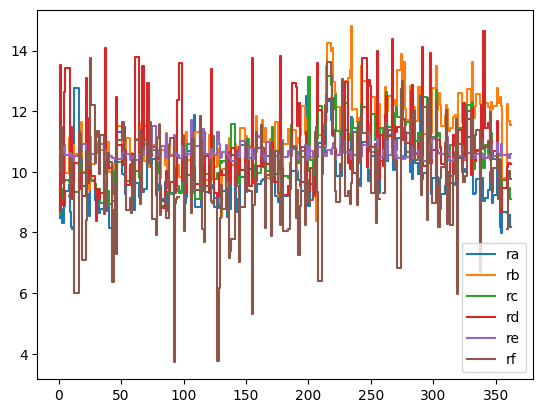

In [21]:
for v in returns:
    plt.step(var["day"], var[v].log(), label=v)
plt.legend()
plt.show()

## Model fitting/prediction

In [22]:
windows = [1, 5, 10, 21, 42]


In [23]:
from collections.abc import Callable, Sequence

def make_features_targets(
    var: pl.DataFrame,
    cols: Sequence[str],
    windows: Sequence[int] = tuple(windows),
    horizon: int = 21,
    day_col: str = "day",
    drop_nulls: bool = False,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    var = var.sort(day_col)
    target_fn = lambda e: e.rolling_mean(horizon).shift(-horizon)

    feature_exprs = [
        pl.col(c).ewm_mean(half_life=w).log().alias(f"{c}" + (f"_ewma{w}" if w != 1 else ""))
        for c in cols
        for w in windows
    ]

    target_exprs = [target_fn(pl.col(c)).alias(f"{c}_fwd") for c in cols]

    combined = var.select(pl.col(day_col), *feature_exprs, *target_exprs)
    if drop_nulls:
        combined = combined.drop_nulls()  # trims the window head + horizon tail

    feat_names = [e.meta.output_name() for e in feature_exprs]
    tgt_names = [e.meta.output_name() for e in target_exprs]
    return combined.select(day_col, *feat_names), combined.select(day_col, *tgt_names)

In [24]:
X, y = make_features_targets(
    var,
    returns,
    windows=windows,
    horizon=21,
    drop_nulls=False,
)
print("X:", X.shape, " y:", y.shape)
display(X.head())
display(y.head())

X: (252, 31)  y: (252, 7)


day,ra,ra_ewma5,ra_ewma10,ra_ewma21,ra_ewma42,rb,rb_ewma5,rb_ewma10,rb_ewma21,rb_ewma42,rc,rc_ewma5,rc_ewma10,rc_ewma21,rc_ewma42,rd,rd_ewma5,rd_ewma10,rd_ewma21,rd_ewma42,re,re_ewma5,re_ewma10,re_ewma21,re_ewma42,rf,rf_ewma5,rf_ewma10,rf_ewma21,rf_ewma42
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,8.482332,8.482332,8.482332,8.482332,8.482332,10.249505,10.249505,10.249505,10.249505,10.249505,8.578546,8.578546,8.578546,8.578546,8.578546,8.702292,8.702292,8.702292,8.702292,8.702292,10.397392,10.397392,10.397392,10.397392,10.397392,10.043449,10.043449,10.043449,10.043449,10.043449
2,9.204191,9.09677,9.081821,9.073883,9.070252,10.624768,10.560781,10.552097,10.547509,10.545415,9.174353,9.081226,9.068373,9.061559,9.058445,13.123827,12.906023,12.873665,12.85625,12.848229,10.598894,10.562072,10.557152,10.55456,10.553379,10.436827,10.370231,10.36118,10.356396,10.354212
3,8.977237,8.983185,8.980002,8.977955,8.976938,10.243759,10.337958,10.346566,10.350734,10.35255,9.322696,9.224455,9.208877,9.200456,9.196571,12.298556,12.439921,12.444365,12.445456,12.44567,10.517337,10.521426,10.520729,10.520247,10.520002,11.154313,10.942858,10.911874,10.895341,10.887763
4,8.680133,8.823601,8.8365,8.842581,8.845184,10.117089,10.244653,10.260259,10.268166,10.27169,9.212044,9.189342,9.180964,9.176031,9.173665,11.574431,12.090123,12.131766,12.151318,12.159688,10.578554,10.555451,10.551926,10.550019,10.549139,10.611774,10.69005,10.687694,10.685326,10.683996
5,8.790897,8.83977,8.847717,8.85171,8.85347,10.576263,10.448662,10.436917,10.431352,10.428959,9.484009,9.343196,9.320761,9.308635,9.303044,12.261878,12.265579,12.274255,12.27887,12.280944,10.706422,10.628768,10.617925,10.612254,10.609683,9.885837,10.390432,10.428094,10.445271,10.452499


day,ra_fwd,rb_fwd,rc_fwd,rd_fwd,re_fwd,rf_fwd
i64,f64,f64,f64,f64,f64,f64
1,29694.021249,43271.160184,18809.093228,159107.595622,41543.319554,82660.179229
2,29531.933583,43794.289038,18770.622784,124078.516826,41427.864198,84791.591705
3,29492.925957,44107.685125,18782.589223,124108.522332,41672.473429,81160.425013
4,29610.389208,45231.206457,18735.696901,124268.496895,42307.536339,83933.855543
5,29552.104025,45794.828398,18378.751731,110533.540641,42066.846364,84194.98093


### GARCH benchmark

In [25]:
from arch import arch_model


def fit_garch(returns, p=1, q=1):
    model = arch_model(returns, vol="Garch", p=p, q=q, rescale=True)
    res = model.fit(disp="off")
    print(res.summary())
    return res


def garch_predict(res):
    forecast = res.forecast(horizon=21, reindex=False)
    # Sum daily variances over 21 days for monthly variance
    monthly_var = forecast.variance.iloc[-1].sum()
    return np.sqrt(monthly_var)
    # monthly_vol_ann = np.sqrt(monthly_var * 252 / 21) / 100  # if rescaled to pct
    # print(f"Annualized vol: {monthly_vol_ann:.2%}")

In [26]:
def garch_features(ret_cc, stocks, horizon=21, day_col="day", min_obs=63):
    ret_cc = ret_cc.sort(day_col)
    out = {day_col: ret_cc[day_col]}
    for s in stocks:
        col = f"r{s}"
        r = ret_cc[col].to_numpy()
        filtered = np.full(len(r), np.nan)
        fwd = np.full(len(r), np.nan)
        for i in range(len(r)):
            hist = r[: i + 1]
            hist = hist[np.isfinite(hist)]
            if len(hist) < min_obs:
                continue
            res = arch_model(hist, vol="Garch", p=1, q=1, rescale=True).fit(
                disp="off", show_warning=False
            )
            sc = res.scale  # arch may rescale returns internally; undo it
            fc = res.forecast(horizon=horizon, reindex=False)
            filtered[i] = np.asarray(res.conditional_volatility)[-1] / sc
            fwd[i] = np.sqrt(fc.variance.to_numpy()[-1].mean()) / sc
        out[f"r{s}_garch"] = filtered
        out[f"r{s}_garch_fwd"] = fwd
    return pl.DataFrame(out).with_columns(pl.exclude(day_col).fill_nan(None))

In [27]:
garch = garch_features(ret_cc, stocks, horizon=21)
display(garch.head())

# join GARCH columns onto X (drop stale columns so re-running stays idempotent)
garch_cols = [c for c in X.columns if c.endswith("_garch") or c.endswith("_garch_fwd")]
if garch_cols:
    X = X.drop(garch_cols)
X = X.join(garch, on="day", how="left")
print("X with GARCH:", X.shape)

day,ra_garch,ra_garch_fwd,rb_garch,rb_garch_fwd,rc_garch,rc_garch_fwd,rd_garch,rd_garch_fwd,re_garch,re_garch_fwd,rf_garch,rf_garch_fwd
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,null,null,null,null,null,null,null,null,null,null,null,null
2,null,null,null,null,null,null,null,null,null,null,null,null
3,null,null,null,null,null,null,null,null,null,null,null,null
4,null,null,null,null,null,null,null,null,null,null,null,null
5,null,null,null,null,null,null,null,null,null,null,null,null


X with GARCH: (252, 43)


## Training and Validation

In [28]:
def get_split(start_month=1, end_month=12, val_ratio = 0.2):
    MONTH = 21
    val_span = int((end_month - start_month + 1) * val_ratio) + 1
    train_span = end_month - start_month - val_span - 1
    assert train_span > 0
    train_start = (start_month - 1) * MONTH
    train_end = (start_month + train_span) * MONTH
    val_start = train_end + MONTH
    val_end = val_start + (val_span - 1) * MONTH - 1
    return (train_start, train_end), (val_start, val_end)

def split_data(X, y, **kwargs):
    (ts, te), (vs, ve) = get_split(**kwargs)
    print("split: ", (ts, te), (vs, ve))
    return (
        (X[ts:te+1], y[ts:te+1]),
        (X[vs:ve+1], y[vs:ve+1]),
    )

## Benchmark: single feature

In [37]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def qlike(y, p):
    r = y / p
    return float(np.mean(r - np.log(r) - 1))


class VarModel:
    def __init__(self, model, features, target):
        if isinstance(model, PassthroughRegressor):
            self.model = model
        else:
            self.model = make_pipeline(StandardScaler(), model)
        self.features, self.target = features, target

    @property
    def estimator(self):
        if isinstance(self.model, PassthroughRegressor):
            return self.model
        return self.model[-1]

    def coefs(self):
        return pl.DataFrame({
            "feature": [*self.features, "intercept"],
            "coef": [*self.estimator.coef_, float(self.estimator.intercept_)],
        }).sort(pl.col("coef").abs(), descending=True)

    def params(self):
        return self.estimator.get_params()

    def _xy(self, X, y):
        df = X.select(self.features).hstack(y.select(self.target)).drop_nulls()
        return df[self.features].to_numpy(), df[self.target].to_numpy().ravel()

    def fit(self, X, y):
        Xn, yn = self._xy(X, y)
        self.model.fit(Xn, np.log(yn))
        return self

    def predict(self, X):
        return np.exp(self.model.predict(X.select(self.features).to_numpy()))

    def score(self, X, y):
        Xn, yn = self._xy(X, y)
        return qlike(yn, np.exp(self.model.predict(Xn)))


# def fit(model, features, target, X, y, start_month=1, val_ratio=0.2):
#     m = VarModel(model, features, target).fit(Xtr, ytr)
#     return m, m.score(Xva, yva)

def simple_search(
    model, 
    features, 
    target, 
    X, 
    y, 
    start_month = 1, 
    val_ratio=0.2, 
    params={},
    draw=False,
):
    (Xtr, ytr), (Xva, yva) = split_data(X, y, start_month=start_month, val_ratio=val_ratio)
    def draw_val(m, s, nv=None):
        print(m.coefs())
        print(f"qlike: {s}")
        plt.plot(yva['day'], var_to_target(yva[target]), label='target')
        plt.plot(yva['day'], var_to_target(m.predict(Xva)), label=f'pred ({nv[0]} = {nv[1]})' if nv else 'pred')
        plt.xlabel('day')
        plt.ylabel('ann. volatility (%)')
        plt.legend()
        plt.show()
    if len(params) > 0:
        ps = [{p: v} for p in params for v in params[p]]
        best = None
        models = {}
        for p in ps:
            n = list(p.items())[0][0]
            v = p[n]
            model.set_params(**p)
            m = VarModel(model, features, target).fit(Xtr, ytr)
            s = m.score(Xva, yva)
            best = (p, s) if best is None or best[1] > s else best
            models[v] = m, s
            draw_val(m, s, (n, p[n]))
    else:
        m = VarModel(model, features, target).fit(Xtr, ytr)
        s = m.score(Xva, yva)
        best = s
        models = {"_": (m, s)}
        draw_val(m, s)
    
    return best, models



In [38]:
from sklearn.base import BaseEstimator, RegressorMixin

class PassthroughRegressor(RegressorMixin, BaseEstimator):
    def __init__(self, col=0):
        self.col = col
        self.coef_ = [1.0]
        self.intercept_ = 0.0

    def fit(self, X, y=None):
        self.is_fitted_ = True

        return self

    def predict(self, Xv):
        return Xv[:, self.col]
        

split:  (0, 168) (189, 230)
shape: (4, 2)
┌───────────┬───────────┐
│ feature   ┆ coef      │
│ ---       ┆ ---       │
│ str       ┆ f64       │
╞═══════════╪═══════════╡
│ intercept ┆ 10.107967 │
│ ra_ewma10 ┆ 1.11233   │
│ ra_ewma21 ┆ -0.915163 │
│ ra_ewma42 ┆ -0.173176 │
└───────────┴───────────┘
qlike: 0.1239349431949193


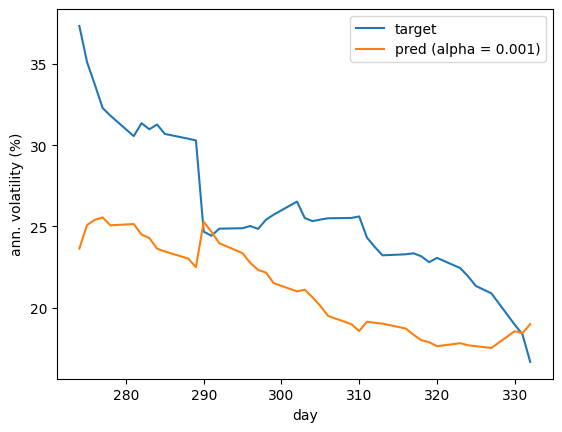

shape: (4, 2)
┌───────────┬───────────┐
│ feature   ┆ coef      │
│ ---       ┆ ---       │
│ str       ┆ f64       │
╞═══════════╪═══════════╡
│ intercept ┆ 10.107967 │
│ ra_ewma10 ┆ 1.096729  │
│ ra_ewma21 ┆ -0.883887 │
│ ra_ewma42 ┆ -0.189541 │
└───────────┴───────────┘
qlike: 0.12178991729559711


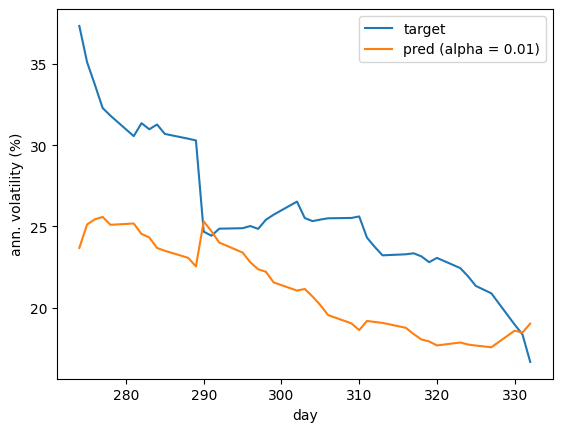

shape: (4, 2)
┌───────────┬───────────┐
│ feature   ┆ coef      │
│ ---       ┆ ---       │
│ str       ┆ f64       │
╞═══════════╪═══════════╡
│ intercept ┆ 10.107967 │
│ ra_ewma10 ┆ 0.984012  │
│ ra_ewma21 ┆ -0.660201 │
│ ra_ewma42 ┆ -0.305451 │
└───────────┴───────────┘
qlike: 0.10704870904568387


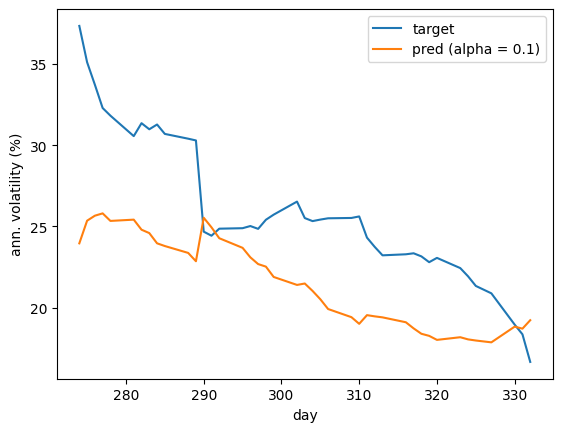

shape: (4, 2)
┌───────────┬───────────┐
│ feature   ┆ coef      │
│ ---       ┆ ---       │
│ str       ┆ f64       │
╞═══════════╪═══════════╡
│ intercept ┆ 10.107967 │
│ ra_ewma10 ┆ 0.721318  │
│ ra_ewma42 ┆ -0.515682 │
│ ra_ewma21 ┆ -0.197545 │
└───────────┴───────────┘
qlike: 0.07766261444702763


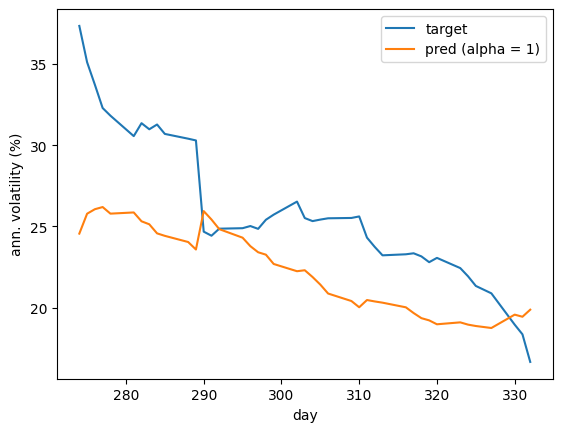

shape: (4, 2)
┌───────────┬───────────┐
│ feature   ┆ coef      │
│ ---       ┆ ---       │
│ str       ┆ f64       │
╞═══════════╪═══════════╡
│ intercept ┆ 10.107967 │
│ ra_ewma10 ┆ 0.414377  │
│ ra_ewma42 ┆ -0.376611 │
│ ra_ewma21 ┆ -0.033694 │
└───────────┴───────────┘
qlike: 0.05723748585509315


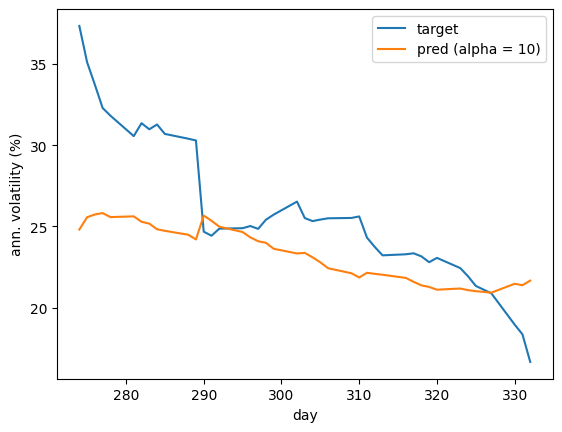

shape: (4, 2)
┌───────────┬───────────┐
│ feature   ┆ coef      │
│ ---       ┆ ---       │
│ str       ┆ f64       │
╞═══════════╪═══════════╡
│ intercept ┆ 10.107967 │
│ ra_ewma10 ┆ 0.08862   │
│ ra_ewma42 ┆ -0.081867 │
│ ra_ewma21 ┆ -0.004227 │
└───────────┴───────────┘
qlike: 0.06081311843143081


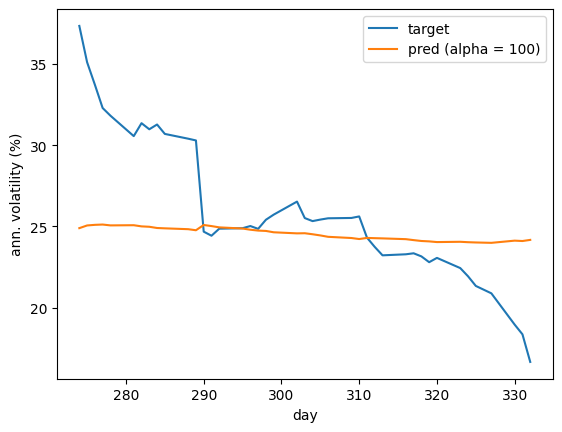

shape: (4, 2)
┌───────────┬───────────┐
│ feature   ┆ coef      │
│ ---       ┆ ---       │
│ str       ┆ f64       │
╞═══════════╪═══════════╡
│ intercept ┆ 10.107967 │
│ ra_ewma10 ┆ 0.047551  │
│ ra_ewma42 ┆ -0.043534 │
│ ra_ewma21 ┆ -0.001936 │
└───────────┴───────────┘
qlike: 0.06300652128259221


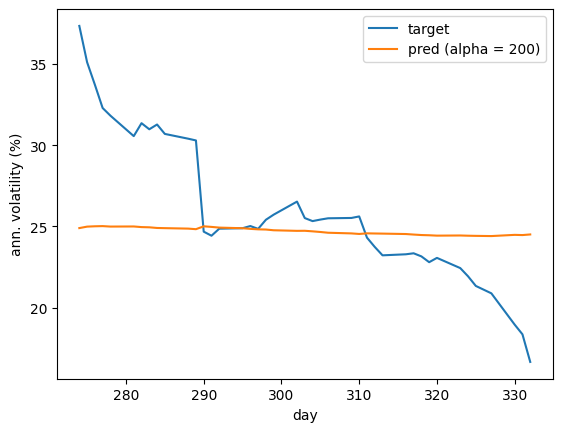

In [39]:
target = "ra_fwd"
features = ['ra_ewma10', 'ra_ewma21', 'ra_ewma42']
alphas = [1e-3, 1e-2, 1e-1, 1, 10, 100, 200]
best, models = simple_search(Ridge(), features, target, X, y, 1, params={"alpha": alphas})



split:  (0, 168) (189, 230)
shape: (2, 2)
┌───────────┬──────┐
│ feature   ┆ coef │
│ ---       ┆ ---  │
│ str       ┆ f64  │
╞═══════════╪══════╡
│ ra_ewma10 ┆ 1.0  │
│ intercept ┆ 0.0  │
└───────────┴──────┘
qlike: 0.1373192631987137


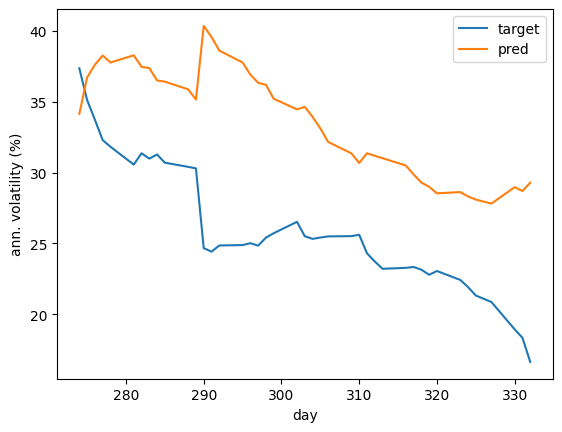

In [40]:
target = "ra_fwd"
feature = 'ra_ewma10'
# display(X[[feature]])
best, models = simple_search(PassthroughRegressor(), [feature], target, X[[feature, 'day']], y, 1)